In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def extract_regions(df, suffix):
    return sorted([col.replace(suffix, "") 
                   for col in df.columns if col.endswith(suffix)])

In [21]:
def convert_long(df, mode,name):
    suffix = f"_{mode}_{name}"
    value_cols = [c for c in df.columns if c.endswith(suffix)]
    
    df_long = df.melt(
        id_vars="year",
        value_vars=value_cols,
        var_name="region_full",
        value_name=mode
    )
    df_long["17region"] = df_long["region_full"].str.replace(suffix, "", regex=False)
    df_long = df_long.drop(columns=["region_full"])
    return df_long

In [22]:
region_name_map = {
    "USA": "USA",
    "XE25": "EU",
    "XER": "Rest of EU",
    "TUR": "Turkey",
    "XOC": "Oceania",
    "CHN": "China",
    "IND": "India",
    "JPN": "Japan",
    "XSE": "Rest of SE Asia",
    "XSA": "Rest of Asia",
    "CAN": "Canada",
    "BRA": "Brazil",
    "XLM": "Latin America",
    "CIS": "Former USSR",
    "XME": "Middle East",
    "XNF": "North Africa",
    "XAF": "Sub-Sahara Africa",
    "WLD": "World"
}

In [23]:
def main(name):
    df_basin  = pd.read_csv(f"../../CSV/moran/basin_{name}_moran_3f.csv")
    df_region = pd.read_csv(f"../../CSV/moran/region_{name}_moran_3f.csv")
    df_world  = pd.read_csv("../../CSV/moran/world_moran_3f.csv")

    regions = extract_regions(df_basin, f"_basin_{name}")

    df_basin_long  = convert_long(df_basin,  mode="basin",  name=name)
    df_region_long = convert_long(df_region, mode="region", name=name)

    df_merged = pd.merge(
        df_basin_long, df_region_long,
        on=["year", "17region"], how="inner"
    )

    # ===== 加上 World =====
    # regions_all = regions + ["World"]
    regions_all = regions 
    n = len(regions_all)
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, 9),
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    for i, reg in enumerate(regions_all):
        ax = axes[i]

        # ---------- 17 regions ----------
        if reg != "World":
            d = df_merged[df_merged["17region"] == reg]
            ax.plot(d["year"], d["basin"],  color="blue", label="Basin",linewidth=2)
            ax.plot(d["year"], d["region"], color="red",  label="Region",linewidth=2)
            

        # # ---------- World ----------
        # else:
        #     ax.plot(df_world["year"], df_world[f"basin_{name}"],
        #             color="blue", label="Basin")
        #     ax.plot(df_world["year"], df_world[f"region_{name}"],
        #             color="red", label="Region")

        title = region_name_map.get(reg, reg)
        ax.set_title(title, fontsize=14)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)        
# ---------- 行列位置 ----------
        row = i // ncols
        col = i % ncols

        # 左列只显示中间行的 y 轴标签
        mid_row = nrows // 2

        if col == 0:
            # 最左列：所有行都显示 y 轴刻度数字
            ax.tick_params(axis="y", labelleft=True)

            # 只在中间行放一次 y 轴标题
            if row == mid_row:
                ax.set_ylabel("Global Moran's I", fontsize=14)
        else:
            # 其他列：完全关闭 y 轴
            ax.tick_params(axis="y",labelleft=False)



        # 底行显示 x 轴
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=14)
            ax.tick_params(axis="x", labelbottom=True)
        else:
            ax.tick_params(axis="x", labelbottom=False)

    # ---------- legend（只放一次） ----------
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.8, 0.1),
        ncol=1,
        fontsize=14
    )


    # ---------- 删除多余子图 ----------
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(
        f"../../plot/moran/17regions_plus_world_{name}_moran.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()


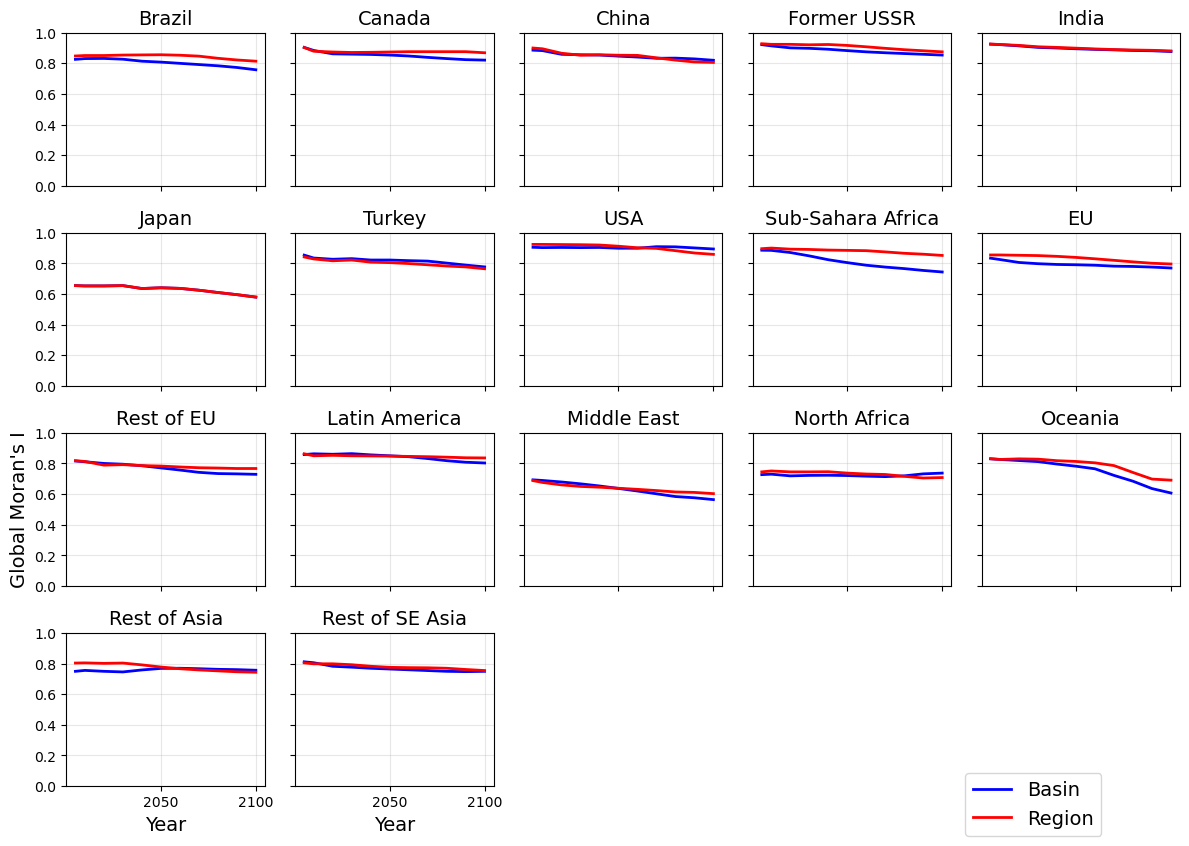

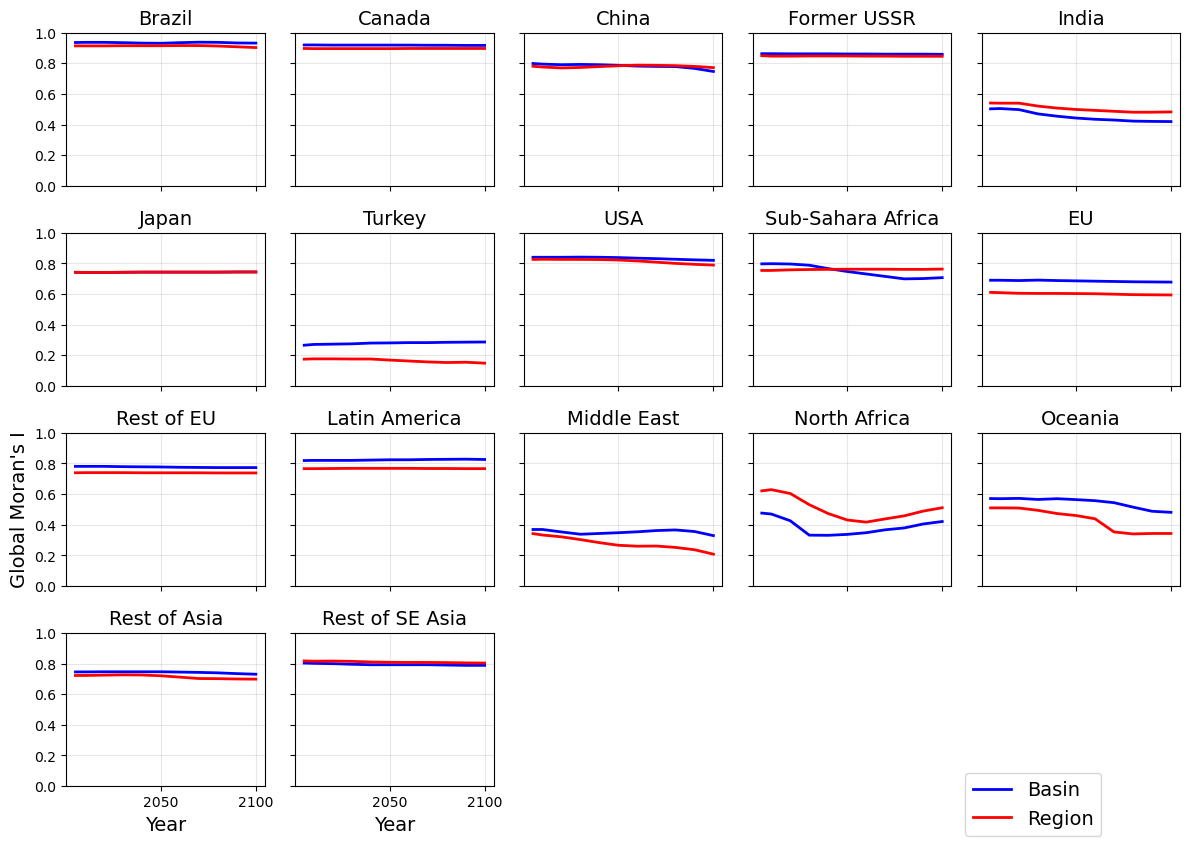

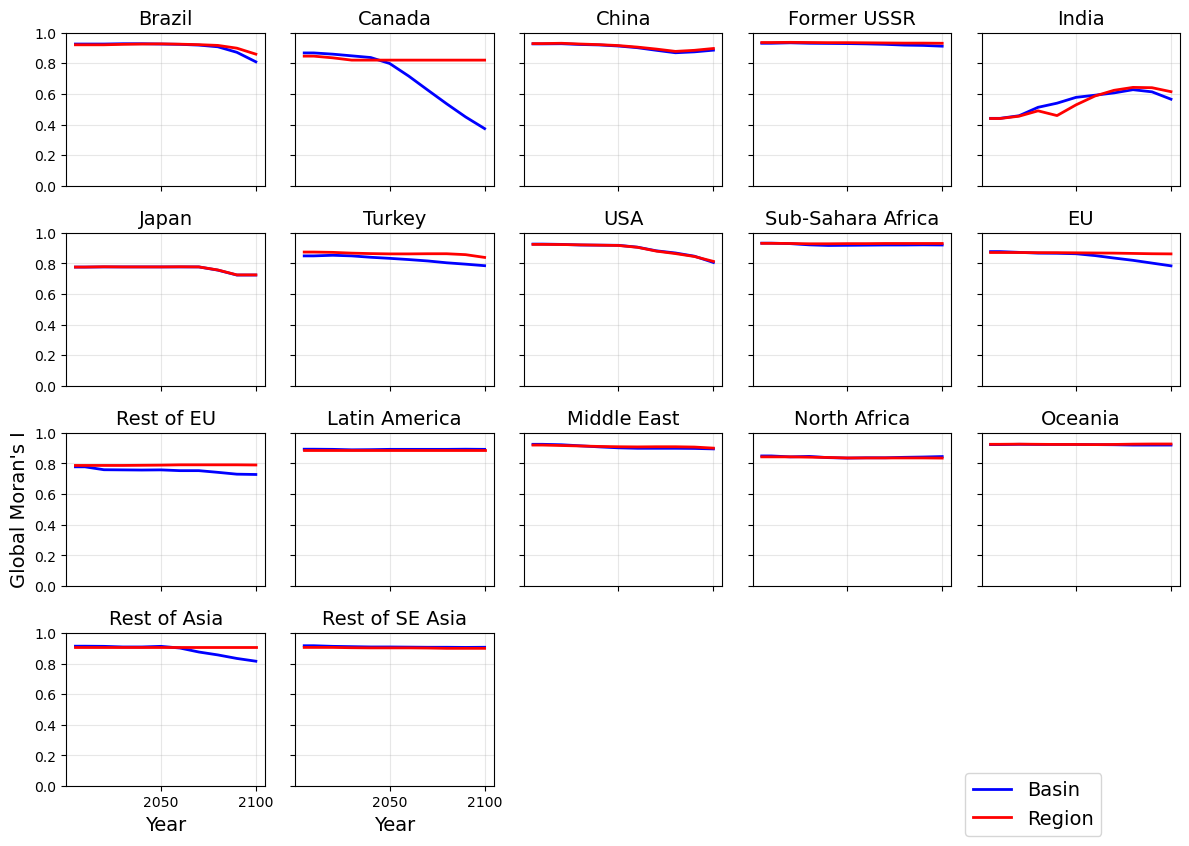

In [24]:
names=["agri","forest","grassland"]

for name in names:
    main(name)